<a href="https://colab.research.google.com/github/nknak-crypto/Machine-Learning-Supervisado/blob/main/Grupo_9_TP5_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Scoring

## Trabajo Práctico N°5 — Machine Learning Supervisado 2026

GRUPO 9: Knak, Guasti & Vicente

In [1]:
# ============================================================
# 1. Cargar librerías
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import LabelEncoder

In [5]:
# ============================================================
# 2. Leer archivo
# ============================================================

# Cargamos el archivo CSV
df = pd.read_csv("/content/TP credit_scoring_dataset.csv")

# Vemos las primeras filas
display(df.head(10))

,Age,Education_Level,Employment_Status,Marital_Status,Monthly_Income,Savings,Loans_Outstanding,Credit_Card_Debt,Missed_Payments,Monthly_Expenses,Credit_Score
0,44,secondary,employed,widowed,2426,16087,0,8715,2,1074.65,8
1,49,none,employed,widowed,6527,4304,4,5363,0,5089.27,11
2,59,tertiary,student,widowed,3857,9598,1,8890,3,3376.01,0
3,26,primary,employed,married,2872,12205,0,1605,3,1685.48,5
4,35,tertiary,self-employed,widowed,7563,1272,4,9065,1,6372.40,9
5,58,secondary,self-employed,single,5942,558,0,6288,5,3238.30,0
6,44,tertiary,unemployed,married,4029,10937,2,7397,0,3306.11,5
7,42,primary,employed,single,2503,12403,1,7783,2,980.29,0
8,55,primary,self-employed,widowed,7140,8752,1,275,3,4750.71,15
9,26,secondary,self-employed,single,1985,17350,1,2354,0,694.52,30


In [6]:
# ============================================================
# 3. EDA - Exploración inicial de datos
# ============================================================

from IPython.display import display, HTML

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">📊 Exploración inicial de datos</h2>'))

# Revisamos el tamaño del dataset
print("Forma del dataset:", df.shape)

Forma del dataset: (1000, 11)


In [7]:
display(HTML('<h3 style="color:#1a5276; font-family:Arial;">🔍 Información general</h3>'))
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                1000 non-null   int64  
 1   Education_Level    1000 non-null   object 
 2   Employment_Status  1000 non-null   object 
 3   Marital_Status     1000 non-null   object 
 4   Monthly_Income     1000 non-null   int64  
 5   Savings            1000 non-null   int64  
 6   Loans_Outstanding  1000 non-null   int64  
 7   Credit_Card_Debt   1000 non-null   int64  
 8   Missed_Payments    1000 non-null   int64  
 9   Monthly_Expenses   1000 non-null   float64
 10  Credit_Score       1000 non-null   int64  
dtypes: float64(1), int64(7), object(3)
memory usage: 86.1+ KB


In [8]:
display(HTML('<h3 style="color:#1a5276; font-family:Arial;">❌ Valores nulos</h3>'))
print(df.isnull().sum())

Age                  0
Education_Level      0
Employment_Status    0
Marital_Status       0
Monthly_Income       0
Savings              0
Loans_Outstanding    0
Credit_Card_Debt     0
Missed_Payments      0
Monthly_Expenses     0
Credit_Score         0
dtype: int64


In [9]:
display(HTML('<h3 style="color:#1a5276; font-family:Arial;">📈 Estadísticas descriptivas</h3>'))
display(df.describe())

,Age,Monthly_Income,Savings,Loans_Outstanding,Credit_Card_Debt,Missed_Payments,Monthly_Expenses,Credit_Score
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,43.213000,3883.606000,10079.640000,2.017000,5045.57300,2.540000,2444.927430,5.931000
std,15.120392,2213.207956,5764.272407,1.418705,2885.31952,1.699202,1649.691199,8.306819
min,18.000000,203.000000,50.000000,0.000000,2.00000,0.000000,69.100000,0.000000
25%,30.000000,1982.500000,5213.250000,1.000000,2519.25000,1.000000,1084.520000,0.000000
50%,43.500000,3749.000000,9740.000000,2.000000,5088.50000,3.000000,2085.565000,1.000000
75%,56.250000,5780.000000,15115.000000,3.000000,7620.50000,4.000000,3580.592500,10.000000
max,69.000000,7991.000000,19995.000000,4.000000,9998.00000,5.000000,7287.740000,38.000000


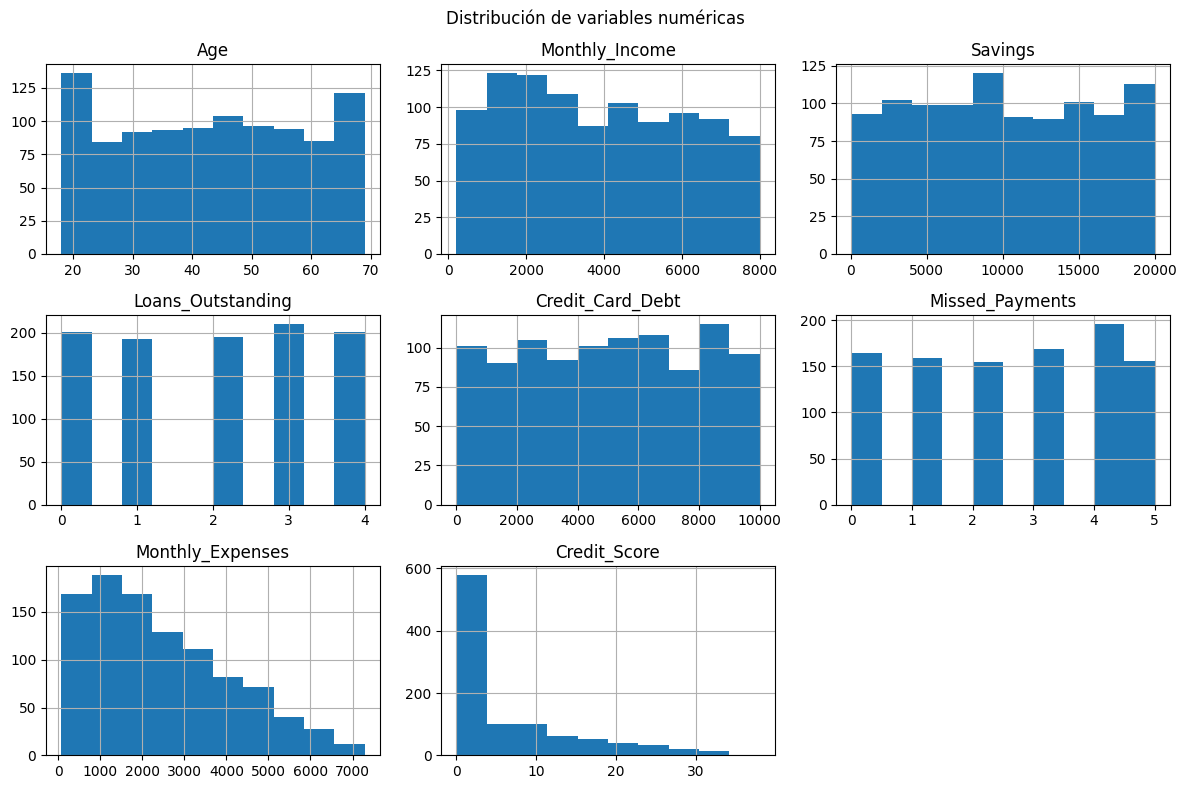

In [10]:
display(HTML('<h3 style="color:#1a5276; font-family:Arial;">📊 Distribución de variables numéricas</h3>'))
df.hist(figsize=(12, 8))
plt.suptitle("Distribución de variables numéricas")
plt.tight_layout()
plt.show()

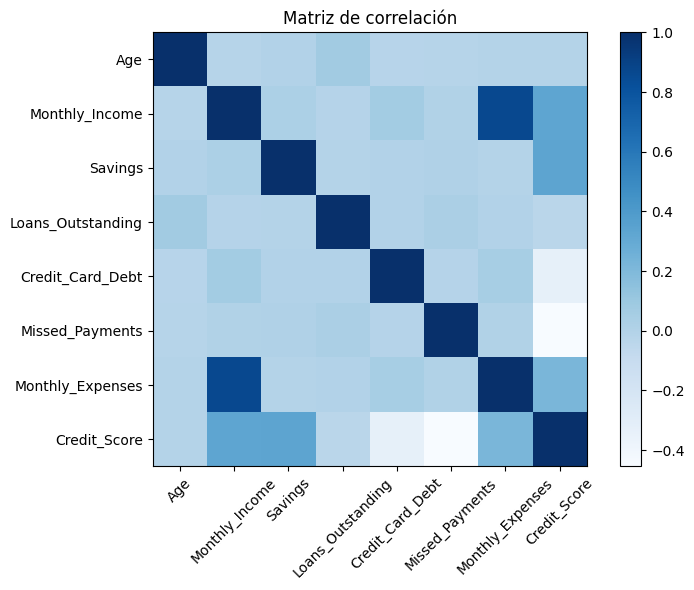

In [11]:
display(HTML('<h3 style="color:#1a5276; font-family:Arial;">🔗 Matriz de correlación</h3>'))
correlacion = df.corr(numeric_only=True)

plt.figure(figsize=(8, 6))
plt.imshow(correlacion, cmap="Blues")
plt.colorbar()
plt.xticks(range(len(correlacion.columns)), correlacion.columns, rotation=45)
plt.yticks(range(len(correlacion.columns)), correlacion.columns)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

El dataset cuenta con 1.000 registros y 11 variables, sin valores nulos. Las variables predictoras incluyen datos demográficos (edad, educación, estado civil), financieros (ingresos, ahorros, deudas) y de comportamiento de pago (pagos perdidos). La variable objetivo Credit_Score presenta una distribución fuertemente asimétrica, con una concentración importante de valores en 0, lo que anticipa un desbalance de clases entre buenos y malos pagadores. La matriz de correlación no muestra multicolinealidad severa entre las variables predictoras, lo que es favorable para el modelo.

In [12]:
# ============================================================
# 4. Definir variable objetivo
# ============================================================

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">🎯 Variable objetivo</h2>'))

# Credit_Score es numérica (0-38).
# La convertimos en clasificación binaria:
# Score = 0  →  Mal pagador (0)
# Score > 0  →  Buen pagador (1)

df["Buen_Pagador"] = (df["Credit_Score"] > 0).astype(int)

print("Distribución de la variable objetivo:")
print(df["Buen_Pagador"].value_counts())
print()
print("Proporción:")
print(df["Buen_Pagador"].value_counts(normalize=True).round(2))

Distribución de la variable objetivo:
Buen_Pagador
1    502
0    498
Name: count, dtype: int64

Proporción:
Buen_Pagador
1    0.5
0    0.5
Name: proportion, dtype: float64


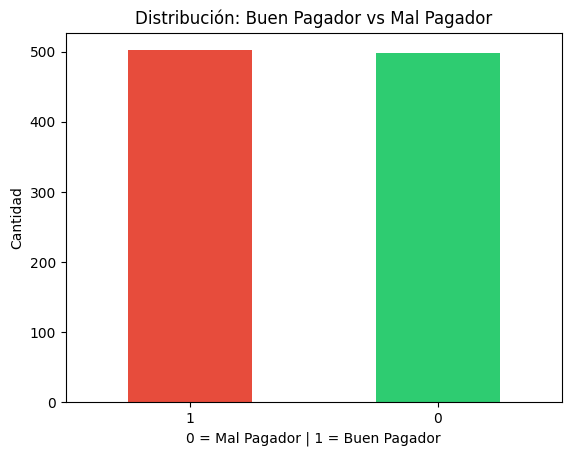

In [13]:
# Visualizamos la distribución
df["Buen_Pagador"].value_counts().plot(kind="bar", color=["#e74c3c", "#2ecc71"])
plt.title("Distribución: Buen Pagador vs Mal Pagador")
plt.xlabel("0 = Mal Pagador | 1 = Buen Pagador")
plt.ylabel("Cantidad")
plt.xticks(rotation=0)
plt.show()

Al binarizar la variable objetivo, se observa que el dataset quedó prácticamente balanceado: 502 buenos pagadores (50%) y 498 malos pagadores (50%). Esto es favorable para el modelo, ya que dispone de ejemplos similares de ambas clases para aprender, y permite que métricas como el accuracy sean confiables.

In [14]:
# ============================================================
# 5. Generar X e y
# ============================================================

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">✂️ Variables predictoras y objetivo</h2>'))

# Definimos la variable objetivo
variable_objetivo = "Buen_Pagador"

# X son las variables predictoras
# Sacamos Credit_Score (la original) y Buen_Pagador (la que queremos predecir)
X = df.drop(columns=["Credit_Score", variable_objetivo])

# y es la variable objetivo
y = df[variable_objetivo]

# Revisamos X
display(X.head())

,Age,Education_Level,Employment_Status,Marital_Status,Monthly_Income,Savings,Loans_Outstanding,Credit_Card_Debt,Missed_Payments,Monthly_Expenses
0,44,secondary,employed,widowed,2426,16087,0,8715,2,1074.65
1,49,none,employed,widowed,6527,4304,4,5363,0,5089.27
2,59,tertiary,student,widowed,3857,9598,1,8890,3,3376.01
3,26,primary,employed,married,2872,12205,0,1605,3,1685.48
4,35,tertiary,self-employed,widowed,7563,1272,4,9065,1,6372.40


In [15]:
# Revisamos y
print("Variable objetivo:")
print(y.head())

Variable objetivo:
0    1
1    1
2    0
3    1
4    1
Name: Buen_Pagador, dtype: int64


In [16]:
# ============================================================
# 6. Imputación de datos
# ============================================================

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">🔧 Imputación de datos</h2>'))

# Revisamos valores nulos en X
print("Valores nulos en X:")
print(X.isnull().sum())

# Imputamos variables numéricas con la mediana
for columna in X.columns:
    if X[columna].dtype in ["int64", "float64"]:
        X[columna] = X[columna].fillna(X[columna].median())

# Imputamos variables categóricas con la moda
for columna in X.columns:
    if X[columna].dtype == "object":
        X[columna] = X[columna].fillna(X[columna].mode()[0])

print("\nValores nulos después de imputar:")
print(X.isnull().sum())

Valores nulos en X:
Age                  0
Education_Level      0
Employment_Status    0
Marital_Status       0
Monthly_Income       0
Savings              0
Loans_Outstanding    0
Credit_Card_Debt     0
Missed_Payments      0
Monthly_Expenses     0
dtype: int64

Valores nulos después de imputar:
Age                  0
Education_Level      0
Employment_Status    0
Marital_Status       0
Monthly_Income       0
Savings              0
Loans_Outstanding    0
Credit_Card_Debt     0
Missed_Payments      0
Monthly_Expenses     0
dtype: int64


El dataset no tiene ningún valor vacío, así que no hubo nada que imputar.



In [18]:
# ============================================================
# 7. Variables Dummy - One Hot Encoding
# ============================================================

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">🔄 One Hot Encoding</h2>'))

# Identificamos las columnas categóricas
columnas_categoricas = ["Education_Level", "Employment_Status", "Marital_Status"]

# Aplicamos One Hot Encoding
encoder_ohe = OneHotEncoder(drop="first", sparse_output=False)

# Transformamos las columnas categóricas
X_encoded = encoder_ohe.fit_transform(X[columnas_categoricas])

# Creamos un dataframe con los nombres de las nuevas columnas
X_encoded_df = pd.DataFrame(
    X_encoded,
    columns=encoder_ohe.get_feature_names_out(columnas_categoricas),
    index=X.index
)

# Unimos con las columnas numéricas
X_numericas = X.drop(columns=columnas_categoricas)
X = pd.concat([X_numericas, X_encoded_df], axis=1)

print("Columnas después de One Hot Encoding:")
print(list(X.columns))
print()
display(X.head())

Columnas después de One Hot Encoding:
['Age', 'Monthly_Income', 'Savings', 'Loans_Outstanding', 'Credit_Card_Debt', 'Missed_Payments', 'Monthly_Expenses', 'Education_Level_primary', 'Education_Level_secondary', 'Education_Level_tertiary', 'Employment_Status_self-employed', 'Employment_Status_student', 'Employment_Status_unemployed', 'Marital_Status_married', 'Marital_Status_single', 'Marital_Status_widowed']



,Age,Monthly_Income,Savings,Loans_Outstanding,Credit_Card_Debt,Missed_Payments,Monthly_Expenses,Education_Level_primary,Education_Level_secondary,Education_Level_tertiary,Employment_Status_self-employed,Employment_Status_student,Employment_Status_unemployed,Marital_Status_married,Marital_Status_single,Marital_Status_widowed
0,44,2426,16087,0,8715,2,1074.65,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,49,6527,4304,4,5363,0,5089.27,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,59,3857,9598,1,8890,3,3376.01,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
3,26,2872,12205,0,1605,3,1685.48,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,35,7563,1272,4,9065,1,6372.40,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0


Toma las 3 columnas de texto y las convierte en columnas de 0 y 1 para que el modelo pueda entenderlas, ya que los árboles de decisión solo trabajan con números.

In [19]:
# ============================================================
# 8. Dividir en Training y Testing
# ============================================================

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">✂️ Training y Testing</h2>'))

# 70% entrenamiento, 30% prueba
# stratify mantiene la proporción de clases en ambos conjuntos

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Tamaños de los conjuntos:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Tamaños de los conjuntos:
X_train: (700, 16)
X_test: (300, 16)
y_train: (700,)
y_test: (300,)


Divide el dataset en dos partes:

* Training70% - El modelo aprende
Elemento de la lista con estos datos.

* Testing30% - Evaluamos qué tan bien aprendió con datos que nunca vio.

In [20]:
# ============================================================
# 9. Escalar datos
# ============================================================

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">📏 Escalado de datos</h2>'))

# Para un árbol CART NO es necesario escalar los datos.
# Los árboles funcionan con cortes sobre los valores originales,
# no dependen de distancias como KNN.

print("✅ No se necesita escalado para el árbol de decisión CART.")
print()
print("A diferencia de KNN, el árbol no mide distancias entre puntos.")
print("Solo hace preguntas del tipo: ¿Savings > 10.000? ¿Missed_Payments > 2?")
print("Por eso los valores originales funcionan perfectamente.")

✅ No se necesita escalado para el árbol de decisión CART.

A diferencia de KNN, el árbol no mide distancias entre puntos.
Solo hace preguntas del tipo: ¿Savings > 10.000? ¿Missed_Payments > 2?
Por eso los valores originales funcionan perfectamente.


In [21]:
# ============================================================
# 10. Crear el modelo CART
# ============================================================

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">🌳 Modelo Árbol de Decisión</h2>'))

# Creamos el modelo de árbol de decisión
modelo_cart = DecisionTreeClassifier(
    criterion="gini",        # medida de impureza
    max_depth=4,             # máximo 4 niveles de preguntas
    min_samples_split=5,     # mínimo 5 muestras para dividir un nodo
    min_samples_leaf=3,      # mínimo 3 muestras en una hoja
    random_state=42
)

# Entrenamos el modelo
modelo_cart.fit(X_train, y_train)

print("✅ Modelo entrenado correctamente.")

✅ Modelo entrenado correctamente.


In [22]:
# ============================================================
# 11. Hacer predicciones
# ============================================================

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">🔮 Predicciones</h2>'))

# Generamos predicciones con el set de prueba
y_pred = modelo_cart.predict(X_test)

# Generamos probabilidades para la curva ROC
y_prob = modelo_cart.predict_proba(X_test)

# Revisamos algunas predicciones
print("Primeras 10 predicciones:")
print(y_pred[:10])

Primeras 10 predicciones:
[1 0 1 1 0 1 1 0 0 1]


In [23]:
# ============================================================
# 12. Métricas del modelo
# ============================================================

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">📊 Métricas de evaluación</h2>'))

# Accuracy general
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy del modelo:", round(accuracy, 4))
print()

# Reporte completo: Precision, Recall, F1
print(classification_report(
    y_test,
    y_pred,
    target_names=["Mal Pagador", "Buen Pagador"]
))

Accuracy del modelo: 0.7067

              precision    recall  f1-score   support

 Mal Pagador       0.66      0.85      0.74       149
Buen Pagador       0.79      0.56      0.66       151

    accuracy                           0.71       300
   macro avg       0.73      0.71      0.70       300
weighted avg       0.73      0.71      0.70       300



El modelo es bueno detectando malos pagadores (Recall 0.85), que es exactamente lo más importante en credit scoring. Prefiere ser conservador: ante la duda clasifica como mal pagador.
El punto débil es que se pierde el 44% de los buenos pagadores reales (los clasifica como malos cuando no lo son), lo que significa que el banco estaría rechazando clientes que en realidad sí pagarían.

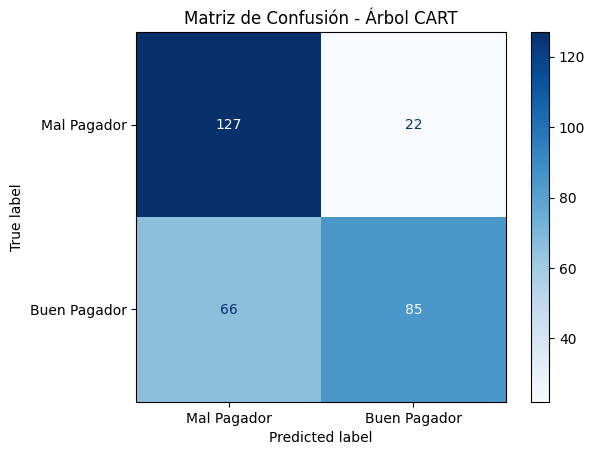

In [24]:
# ============================================================
# 13. Matriz de confusión
# ============================================================

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">🔢 Matriz de Confusión</h2>'))

# Creamos la matriz de confusión
matriz = confusion_matrix(y_test, y_pred)

# Visualizamos
disp = ConfusionMatrixDisplay(
    confusion_matrix=matriz,
    display_labels=["Mal Pagador", "Buen Pagador"]
)

disp.plot(cmap="Blues")
plt.title("Matriz de Confusión - Árbol CART")
plt.show()

* El error más grave es el 22 (arriba derecha): son malos pagadores que el modelo no detectó y el banco les daría el crédito igual.

* El error menos grave es el 66 (abajo izquierda): son buenos clientes que el banco rechaza innecesariamente, pierde negocio pero no pierde plata.

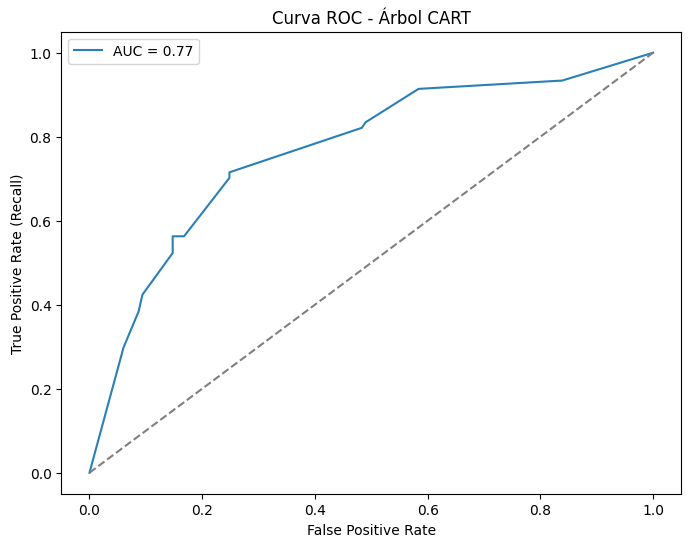

AUC: 0.7681


In [25]:
# ============================================================
# 14. Curva ROC
# ============================================================

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">📈 Curva ROC</h2>'))

# Calculamos la curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
roc_auc = auc(fpr, tpr)

# Graficamos
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}", color="#2980b9")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.title("Curva ROC - Árbol CART")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.legend()
plt.show()

print(f"AUC: {roc_auc:.4f}")

El modelo obtuvo un AUC de 0.77, lo que indica una capacidad aceptable para distinguir entre buenos y malos pagadores. La curva ROC se mantiene consistentemente por encima de la línea base, confirmando que el modelo agrega valor respecto a una clasificación aleatoria.

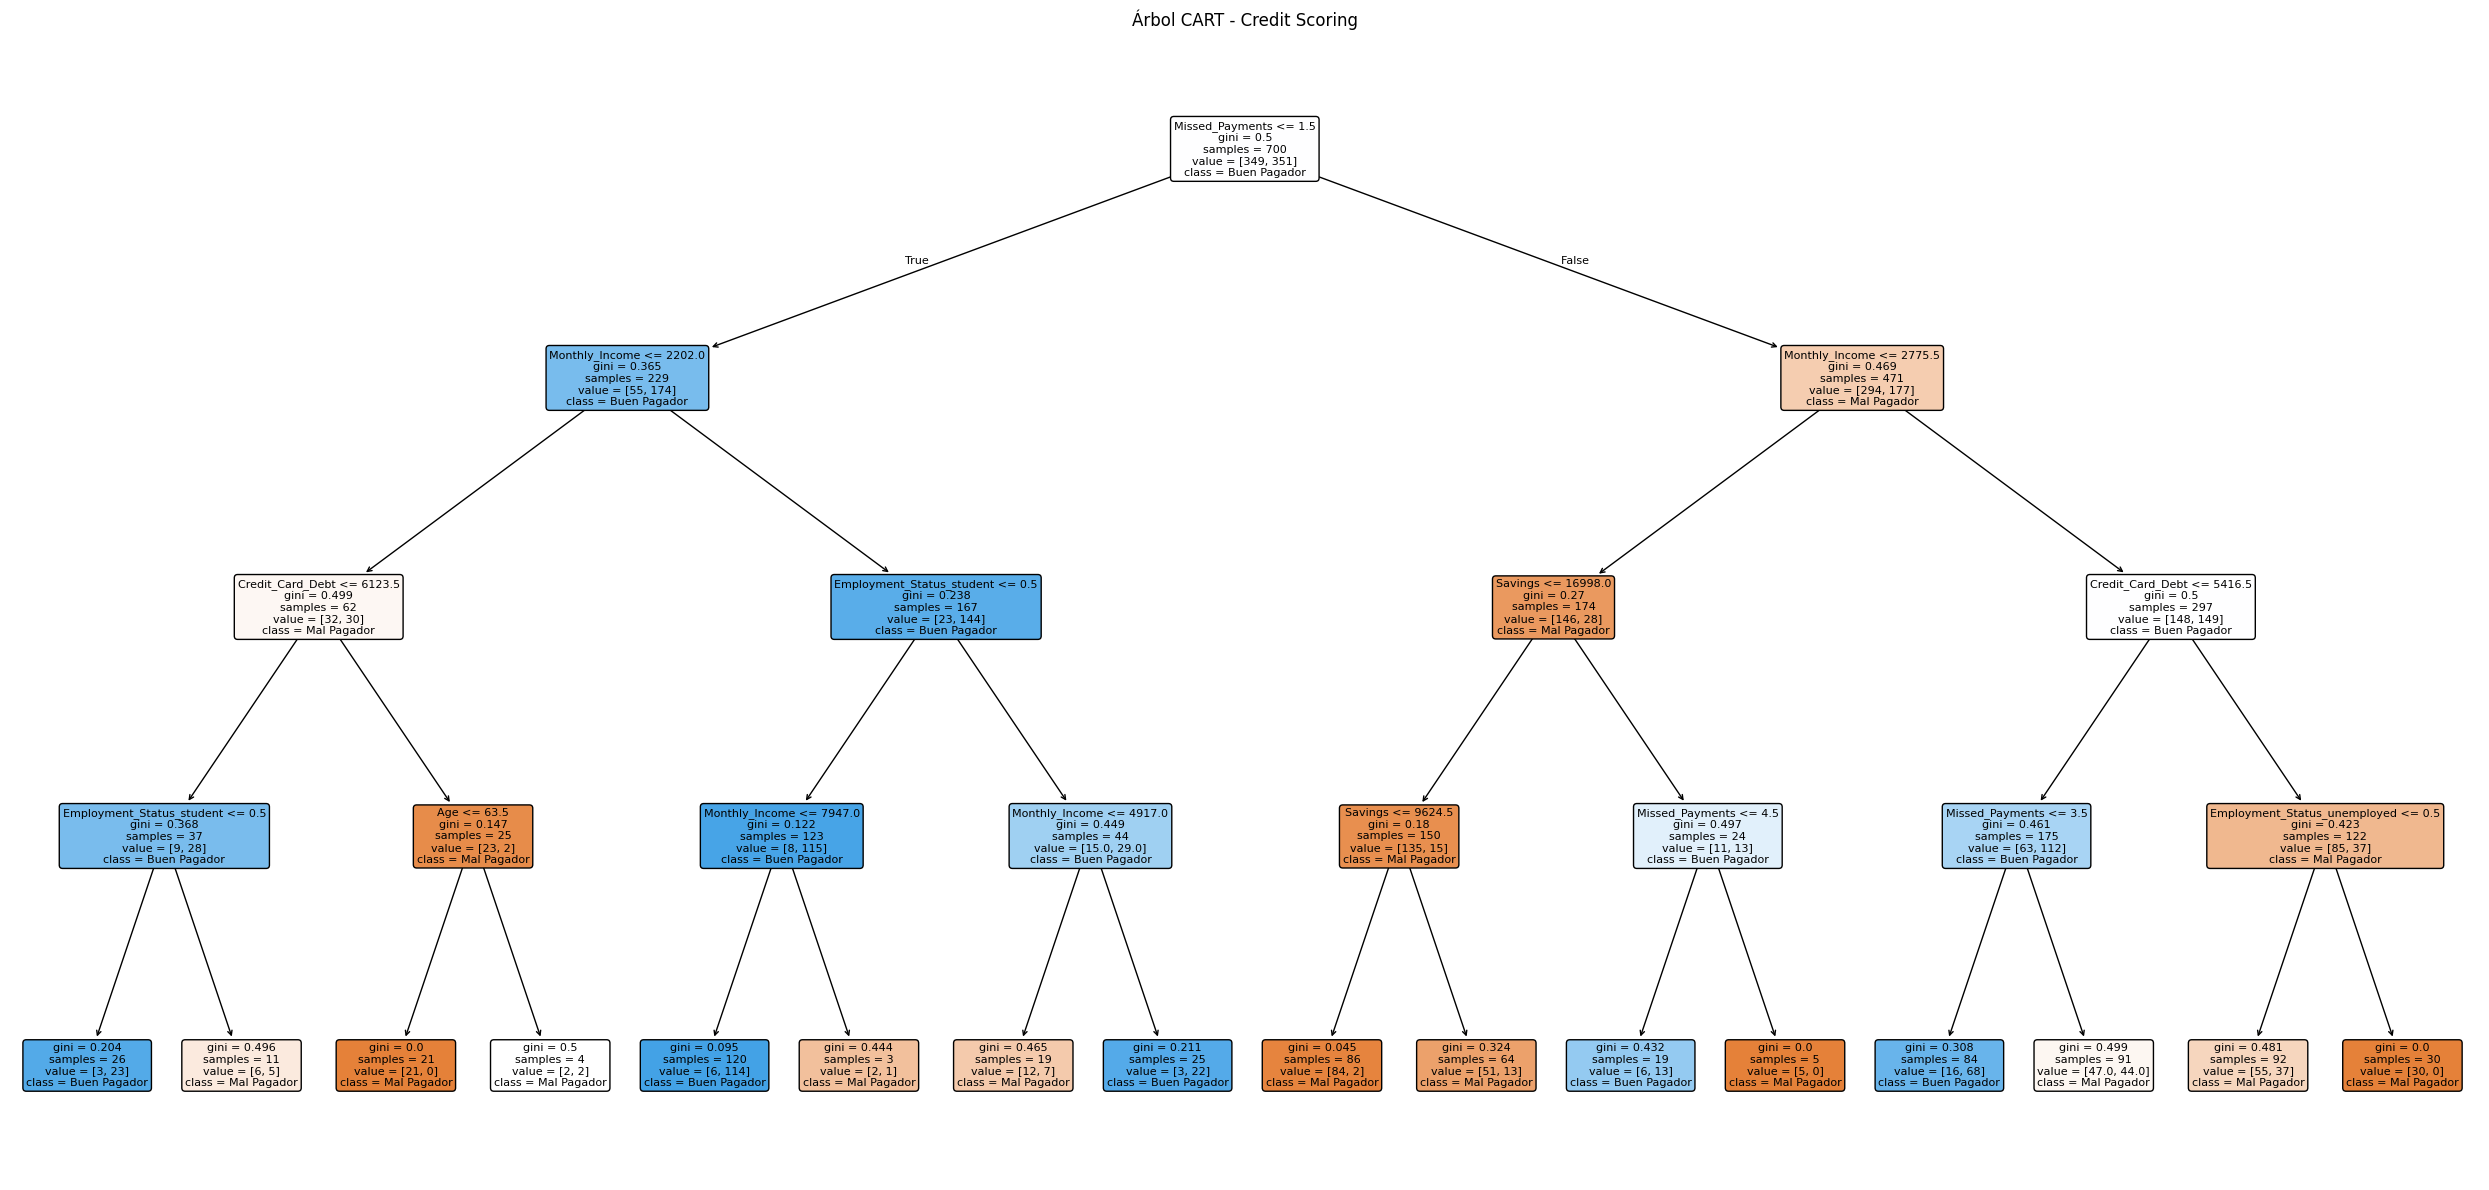

In [28]:
# ============================================================
# 15. Visualizar el árbol
# ============================================================

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">🌳 Visualización del Árbol</h2>'))

plt.figure(figsize=(25, 12))

plot_tree(
    modelo_cart,
    feature_names=X.columns,
    class_names=["Mal Pagador", "Buen Pagador"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Árbol CART - Credit Scoring")
plt.tight_layout()
plt.show()

,Variable,Importancia
0,Missed_Payments,0.360849
1,Monthly_Income,0.285932
2,Credit_Card_Debt,0.185040
3,Savings,0.064503
4,Employment_Status_student,0.048114
5,Employment_Status_unemployed,0.045189
6,Age,0.010374
7,Loans_Outstanding,0.000000
8,Education_Level_primary,0.000000
9,Monthly_Expenses,0.000000


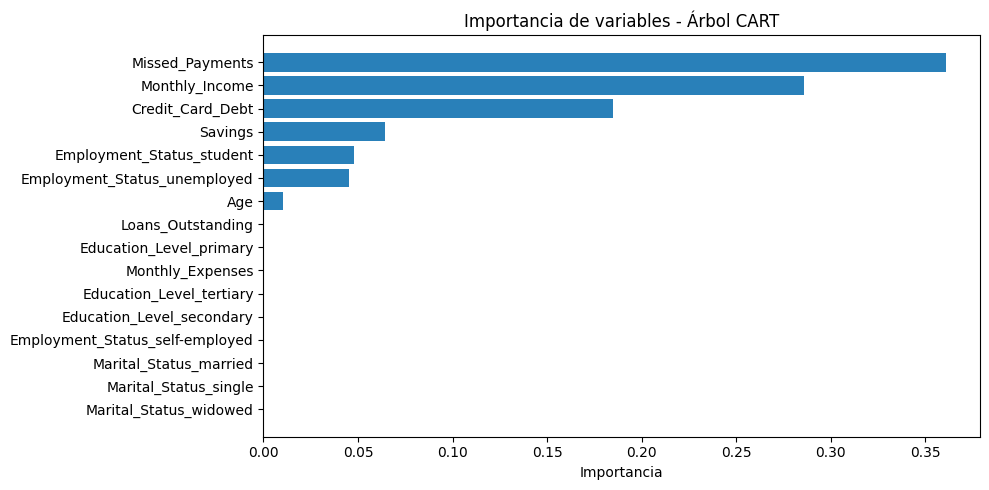

In [29]:
# ============================================================
# 16. Importancia de variables
# ============================================================

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">⭐ Importancia de variables</h2>'))

# Tabla con la importancia de cada variable
importancia = pd.DataFrame({
    "Variable": X.columns,
    "Importancia": modelo_cart.feature_importances_
})

# Ordenamos de mayor a menor
importancia = importancia.sort_values(by="Importancia", ascending=False).reset_index(drop=True)

display(importancia)

# Graficamos
plt.figure(figsize=(10, 5))
plt.barh(importancia["Variable"], importancia["Importancia"], color="#2980b9")
plt.xlabel("Importancia")
plt.title("Importancia de variables - Árbol CART")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

* Missed_Payments (0.36) → la más importante por lejos. Cuántos pagos perdió el cliente es la mejor señal de si va a pagar o no. Tiene lógica: si ya no pagó antes, probablemente no pague de nuevo.

* Monthly_Income (0.29) → el ingreso mensual. A mayor ingreso, más capacidad de pago.

* Credit_Card_Debt (0.19) → la deuda de tarjeta. Mucha deuda existente es señal de riesgo.

* Las variables de estado civil y educación tienen importancia 0 → el árbol nunca las usó para tomar decisiones. No aportan información útil para predecir si alguien paga o no.

In [30]:
# ============================================================
# 17. Comparar valores reales vs predichos
# ============================================================

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">🔍 Reales vs Predichos</h2>'))

# Mapeamos 0/1 a etiquetas legibles
etiquetas = {0: "Mal Pagador ❌", 1: "Buen Pagador ✅"}

resultados = pd.DataFrame({
    "Real": y_test.map(etiquetas).values,
    "Predicción": pd.Series(y_pred).map(etiquetas).values
})

# Agregamos columna de acierto
resultados["¿Correcto?"] = resultados["Real"] == resultados["Predicción"]
resultados["¿Correcto?"] = resultados["¿Correcto?"].map({True: "✅", False: "❌"})

display(resultados.head(20))

,Real,Predicción,¿Correcto?
0,Buen Pagador ✅,Buen Pagador ✅,✅
1,Buen Pagador ✅,Mal Pagador ❌,❌
2,Buen Pagador ✅,Buen Pagador ✅,✅
3,Buen Pagador ✅,Buen Pagador ✅,✅
4,Mal Pagador ❌,Mal Pagador ❌,✅
5,Buen Pagador ✅,Buen Pagador ✅,✅
6,Buen Pagador ✅,Buen Pagador ✅,✅
7,Buen Pagador ✅,Mal Pagador ❌,❌
8,Buen Pagador ✅,Mal Pagador ❌,❌
9,Mal Pagador ❌,Buen Pagador ✅,❌


In [31]:
# ============================================================
# 18. Predicción para un nuevo cliente
# ============================================================

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">🧑 Predicción nuevo cliente</h2>'))

# Datos del nuevo cliente
nuevo_cliente_raw = pd.DataFrame({
    "Age": [35],
    "Education_Level": ["tertiary"],
    "Employment_Status": ["employed"],
    "Marital_Status": ["single"],
    "Monthly_Income": [5000],
    "Savings": [15000],
    "Loans_Outstanding": [2],
    "Credit_Card_Debt": [3000],
    "Missed_Payments": [0],
    "Monthly_Expenses": [2000.0]
})

display(HTML('<h4 style="color:#1a5276; font-family:Arial;">Perfil del cliente:</h4>'))
display(nuevo_cliente_raw)

# Aplicamos One Hot Encoding igual que en el training
nuevo_cliente_encoded = encoder_ohe.transform(nuevo_cliente_raw[columnas_categoricas])

nuevo_cliente_encoded_df = pd.DataFrame(
    nuevo_cliente_encoded,
    columns=encoder_ohe.get_feature_names_out(columnas_categoricas)
)

nuevo_cliente_numericas = nuevo_cliente_raw.drop(columns=columnas_categoricas)
nuevo_cliente_final = pd.concat([nuevo_cliente_numericas, nuevo_cliente_encoded_df], axis=1)

# Alineamos columnas con el training set
nuevo_cliente_final = nuevo_cliente_final.reindex(columns=X.columns, fill_value=0)

# Hacemos la predicción
prediccion = modelo_cart.predict(nuevo_cliente_final)[0]
probabilidad = modelo_cart.predict_proba(nuevo_cliente_final)[0]

print(f"Predicción: {'Buen Pagador ✅' if prediccion == 1 else 'Mal Pagador ❌'}")
print(f"Probabilidad Mal Pagador: {probabilidad[0]:.2%}")
print(f"Probabilidad Buen Pagador: {probabilidad[1]:.2%}")

,Age,Education_Level,Employment_Status,Marital_Status,Monthly_Income,Savings,Loans_Outstanding,Credit_Card_Debt,Missed_Payments,Monthly_Expenses
0,35,tertiary,employed,single,5000,15000,2,3000,0,2000.0


Predicción: Buen Pagador ✅
Probabilidad Mal Pagador: 5.00%
Probabilidad Buen Pagador: 95.00%


In [33]:
# ============================================================
# 18. Predicción interactiva para un nuevo cliente
# ============================================================

import ipywidgets as widgets
from IPython.display import display, HTML

display(HTML('<h2 style="color:#1a5276; font-family:Arial;">🧑 Predicción nuevo cliente</h2>'))

estilo = {'description_width': 'initial'}

# Inputs numéricos
age      = widgets.IntSlider(value=35, min=18, max=70, description='Edad:', style=estilo)
income   = widgets.IntSlider(value=3000, min=200, max=8000, step=100, description='Ingreso mensual:', style=estilo)
savings  = widgets.IntSlider(value=10000, min=0, max=20000, step=500, description='Ahorros:', style=estilo)
loans    = widgets.IntSlider(value=2, min=0, max=4, description='Préstamos pendientes:', style=estilo)
debt     = widgets.IntSlider(value=3000, min=0, max=10000, step=500, description='Deuda tarjeta:', style=estilo)
missed   = widgets.IntSlider(value=0, min=0, max=5, description='Pagos perdidos:', style=estilo)
expenses = widgets.IntSlider(value=2000, min=0, max=7000, step=100, description='Gastos mensuales:', style=estilo)

# Inputs categóricos
education  = widgets.Dropdown(options=['none', 'primary', 'secondary', 'tertiary'], value='secondary', description='Educación:', style=estilo)
employment = widgets.Dropdown(options=['employed', 'self-employed', 'student', 'unemployed'], value='employed', description='Empleo:', style=estilo)
marital    = widgets.Dropdown(options=['single', 'married', 'divorced', 'widowed'], value='single', description='Estado civil:', style=estilo)

# Botón y output
boton  = widgets.Button(description='Predecir', button_style='primary')
output = widgets.Output()

def predecir(b):
    output.clear_output()
    with output:
        nuevo = pd.DataFrame({
            "Age": [age.value],
            "Education_Level": [education.value],
            "Employment_Status": [employment.value],
            "Marital_Status": [marital.value],
            "Monthly_Income": [income.value],
            "Savings": [savings.value],
            "Loans_Outstanding": [loans.value],
            "Credit_Card_Debt": [debt.value],
            "Missed_Payments": [missed.value],
            "Monthly_Expenses": [float(expenses.value)]
        })

        nuevo_encoded = encoder_ohe.transform(nuevo[columnas_categoricas])
        nuevo_encoded_df = pd.DataFrame(
            nuevo_encoded,
            columns=encoder_ohe.get_feature_names_out(columnas_categoricas)
        )
        nuevo_num   = nuevo.drop(columns=columnas_categoricas)
        nuevo_final = pd.concat([nuevo_num, nuevo_encoded_df], axis=1)
        nuevo_final = nuevo_final.reindex(columns=X.columns, fill_value=0)

        pred = modelo_cart.predict(nuevo_final)[0]
        prob = modelo_cart.predict_proba(nuevo_final)[0]

        if pred == 1:
            display(HTML('<h3 style="color:#27ae60;">✅ Buen Pagador</h3>'))
        else:
            display(HTML('<h3 style="color:#e74c3c;">❌ Mal Pagador</h3>'))

        print(f"Probabilidad Mal Pagador:  {prob[0]:.2%}")
        print(f"Probabilidad Buen Pagador: {prob[1]:.2%}")

boton.on_click(predecir)

display(widgets.VBox([age, income, savings, loans, debt, missed, expenses, education, employment, marital, boton, output]))

Este paso permite simular la llegada de un cliente nuevo al banco. Con los sliders y dropdowns cargás el perfil del cliente (edad, ingresos, ahorros, deudas, pagos perdidos, etc.) y al apretar Predecir el modelo aplica todo lo que aprendió durante el entrenamiento para clasificarlo como buen o mal pagador, mostrando además la probabilidad de cada resultado. Es la aplicación práctica del modelo: en un banco real, este tipo de herramienta automatizaría la evaluación de solicitudes de crédito.

Conclusiones

* Cargamos el dataset de credit scoring con 1.000  clientes y 11 variables sin valores nulos.

* Realizamos un EDA explorando la distribución de variables, estadísticas descriptivas y matriz de correlación.

* Binarizamos la variable Credit_Score creando Buen_Pagador (0 = mal pagador, 1 = buen pagador), obteniendo un dataset perfectamente balanceado (50/50).

* Separamos las variables predictoras (X) de la variable objetivo (y) y aplicamos One Hot Encoding para convertir las variables categóricas en numéricas.

* Dividimos el dataset en 70% entrenamiento y 30% prueba con stratify para mantener la proporción de clases.

* Entrenamos un árbol de decisión CART con criterion gini, max_depth=4 y límites en muestras para evitar overfitting.

* El modelo alcanzó un accuracy de 0.71 y un AUC de 0.77, mostrando capacidad aceptable para distinguir entre buenos y malos pagadores.

* La métrica más relevante fue el Recall de mal pagador (0.85): el modelo detecta correctamente al 85% de los clientes que no pagarían, minimizando el riesgo crediticio del banco.

* Las variables más importantes resultaron ser Missed_Payments, Monthly_Income y Credit_Card_Debt, consistentes con el contexto de negocio.

* Implementamos una interfaz interactiva para predecir el comportamiento de nuevos solicitantes en tiempo real.